In [1]:
# Import the drive module from google.colab to interact with Google Drive
from google.colab import drive

# Mount Google Drive to the Colab environment at '/content/drive'
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Change the current working directory to the specified path in Google Drive
# This assumes the 'Fake News' dataset is located there
%cd /content/drive/My Drive/TUD/Thesis/'Project work'/'Foundational Diffusion Models'

# List the contents of the current directory to verify the files are present
%ls

/content/drive/My Drive/TUD/Thesis/Project work/Foundational Diffusion Models
data/                  improved_ddpm_unet_cifar10.pth  Untitled0.ipynb
ddpm_unet_cifar10.pth  score_sde_unet_cifar10.pth


In [3]:
import torchvision
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)

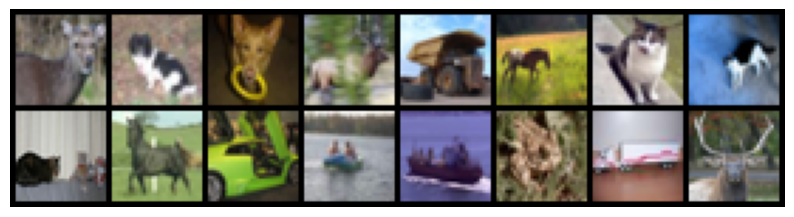

Labels:  deer | dog | dog | deer | truck | horse | cat | cat | cat | horse | car | ship | ship | frog | truck | deer


In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset (converts images to PyTorch tensors)
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Create a dataloader to grab batches of 16 images
trainloader = torch.utils.data.DataLoader(trainset, batch_size=16, shuffle=True)

# CIFAR-10 Class Names
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 2. Grab one batch of random images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 3. Helper function to show the image grid
def imshow(img):
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    # PyTorch uses (Channels, Height, Width), Matplotlib needs (Height, Width, Channels)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Display the grid and print the labels
imshow(torchvision.utils.make_grid(images, nrow=8))
print('Labels: ', ' | '.join(f'{classes[labels[j]]}' for j in range(16)))

Total training images: 50000
Image tensor shape: torch.Size([3, 32, 32]) (Channels, Height, Width)
Current Pixel value range: Min = 0.0000, Max = 1.0000


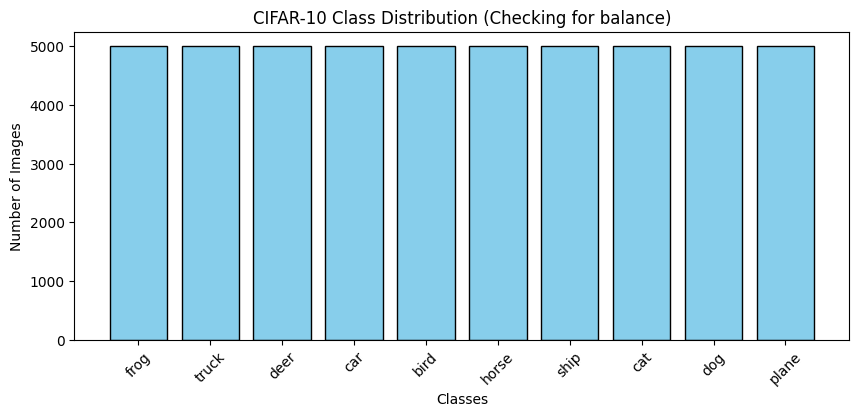

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1. Check dataset size and tensor shapes
print(f"Total training images: {len(trainset)}")
sample_img, sample_label = trainset[0]
print(f"Image tensor shape: {sample_img.shape} (Channels, Height, Width)")
print(f"Current Pixel value range: Min = {sample_img.min().item():.4f}, Max = {sample_img.max().item():.4f}")

# 2. Check class distribution to ensure the dataset is perfectly balanced
labels = [label for _, label in trainset]
class_counts = Counter(labels)

# 3. Plotting the distribution
plt.figure(figsize=(10, 4))
plt.bar([classes[i] for i in class_counts.keys()], class_counts.values(), color='skyblue', edgecolor='black')
plt.title('CIFAR-10 Class Distribution (Checking for balance)')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

In [27]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import GaussianBlur

# 1. Base transformations for the clean images
# Normalizing to mean 0.5, std 0.5 shifts the [0, 1] range to [-1, 1]
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Define the blur transformation to create the degraded inputs
# You can increase the sigma value to make the task harder for the model
blur_transform = GaussianBlur(kernel_size=5, sigma=(2.0, 2.0))

# 3. Custom Dataset wrapper to return Clean and Blurry pairs
class DeblurDataset(torch.utils.data.Dataset):
    def __init__(self, root='./data', train=True):
        self.base_dataset = torchvision.datasets.CIFAR10(
            root=root, train=train, download=False, transform=base_transform
        )

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        clean_img, label = self.base_dataset[idx]

        # Apply blur to create the conditioning input
        blurry_img = blur_transform(clean_img)

        # Returns: (Target Clean Image, Input Blurry Image)
        return clean_img, blurry_img

# 4. Initialize the specific deblurring dataset and dataloader
# We increase batch size to 64 or 128 for actual training
deblur_trainset = DeblurDataset(train=True)
deblur_trainloader = torch.utils.data.DataLoader(deblur_trainset, batch_size=64, shuffle=True)

# 5. Test the dataloader to ensure pairs are generated correctly
clean_batch, blurry_batch = next(iter(deblur_trainloader))
print(f"Clean batch shape: {clean_batch.shape} (Ready for Diffusion Noise)")
print(f"Blurry batch shape: {blurry_batch.shape} (Ready for Model Conditioning)")
print(f"Processed Pixel Range: Min = {clean_batch.min().item():.4f}, Max = {clean_batch.max().item():.4f}")

Clean batch shape: torch.Size([64, 3, 32, 32]) (Ready for Diffusion Noise)
Blurry batch shape: torch.Size([64, 3, 32, 32]) (Ready for Model Conditioning)
Processed Pixel Range: Min = -1.0000, Max = 1.0000


In [28]:
import torch
import torch.nn as nn
import math

class SinusoidalPositionEmbeddings(nn.Module):
    """Encodes the scalar timestep t into a vector embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    """A standard standard ResNet-style block used throughout the U-Net."""
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.transform = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        )
        self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t):
        # First convolution
        h = self.conv1(x)
        # Inject time embedding information
        time_emb = self.time_mlp(t)[:, :, None, None]
        # Combine image features and time embeddings
        h = h + time_emb
        # Second convolution + Residual connection
        return self.transform(h) + self.residual_conv(x)

class SharedUNet(nn.Module):
    """The unified U-Net backbone for DDPM, DDIM, and Score SDE."""
    def __init__(self, in_channels=3, out_channels=3, time_emb_dim=256):
        super().__init__()

        # 1. Time Embedding Network
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )

        # 2. Downsampling Blocks (Encoder)
        self.inc = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.down1 = Block(64, 128, time_emb_dim)
        self.pool1 = nn.MaxPool2d(2) # 32x32 -> 16x16

        self.down2 = Block(128, 256, time_emb_dim)
        self.pool2 = nn.MaxPool2d(2) # 16x16 -> 8x8

        # 3. Bottleneck Middle Block
        self.mid1 = Block(256, 256, time_emb_dim)
        self.mid2 = Block(256, 256, time_emb_dim)

        # 4. Upsampling Blocks (Decoder) with Skip Connections
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) # 8x8 -> 16x16
        # Input channels: 128 (from up1) + 256 (skip from x3) = 384
        self.up_block1 = Block(128 + 256, 128, time_emb_dim)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) # 16x16 -> 32x32
        # Input channels: 64 (from up2) + 128 (skip from x2) = 192
        self.up_block2 = Block(64 + 128, 64, time_emb_dim)

        # 5. Final Output Layer
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x, t):
        # Embed time
        t = self.time_mlp(t)

        # Encoder path & save features for skip connections
        x1 = self.inc(x)         # Shape: [B, 64, 32, 32]
        x2 = self.down1(x1, t)   # Shape: [B, 128, 32, 32]
        p2 = self.pool1(x2)      # Shape: [B, 128, 16, 16]

        x3 = self.down2(p2, t)   # Shape: [B, 256, 16, 16]
        p3 = self.pool2(x3)      # Shape: [B, 256, 8, 8]

        # Bottleneck
        mid = self.mid1(p3, t)   # Shape: [B, 256, 8, 8]
        mid = self.mid2(mid, t)  # Shape: [B, 256, 8, 8]

        # Decoder path with concatenated skip connections
        u1 = self.up1(mid)       # Shape: [B, 128, 16, 16]
        u1 = torch.cat([u1, x3], dim=1) # Concatenate along channels -> [B, 384, 16, 16]
        u1 = self.up_block1(u1, t)

        u2 = self.up2(u1)       # Shape: [B, 64, 32, 32]
        u2 = torch.cat([u2, x2], dim=1) # Concatenate along channels -> [B, 192, 32, 32]
        u2 = self.up_block2(u2, t)

        return self.outc(u2)     # Final shape matches original input: [B, 3, 32, 32]

# --- Quick Verification Test ---
if __name__ == "__main__":
    model = SharedUNet()
    test_input = torch.randn(4, 3, 32, 32) # Batch size 4, CIFAR-10 size
    test_time = torch.randint(0, 1000, (4,)) # 4 random timesteps

    output = model(test_input, test_time)
    print(f"Input shape:  {test_input.shape}")
    print(f"Output shape: {output.shape} (Verification Successful!)")

Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 3, 32, 32]) (Verification Successful!)


In [29]:
import torch
import torch.nn.functional as F

class DDPMScheduler:
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device="cpu"):
        self.num_timesteps = num_timesteps
        self.device = device

        # 1. Define the linear noise schedule (Betas)
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)

        # 2. Calculate Alphas and Cumulative Alphas
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

        # 3. Calculate previous cumulative alphas (needed for reverse step variance)
        # Pad with 1.0 at the beginning so alphas_cumprod_prev[0] = 1.0
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

    def add_noise(self, clean_images, noise, timesteps):
        """
        FORWARD PROCESS: Jumps directly to timestep t to create training data.
        """
        sqrt_alpha_cumprod = torch.sqrt(self.alphas_cumprod[timesteps]).view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod = torch.sqrt(1.0 - self.alphas_cumprod[timesteps]).view(-1, 1, 1, 1)

        noisy_images = sqrt_alpha_cumprod * clean_images + sqrt_one_minus_alpha_cumprod * noise
        return noisy_images

    def step(self, predicted_noise, timestep, current_image):
        """
        REVERSE PROCESS: Takes a single step backwards from t to t-1.
        """
        t = timestep

        # Fetch the pre-calculated variables for this specific timestep
        alpha_t = self.alphas[t]
        alpha_cumprod_t = self.alphas_cumprod[t]
        beta_t = self.betas[t]

        # 1. Calculate the mean (the deterministic part of the reverse step)
        # Formula: 1 / sqrt(alpha_t) * (x_t - (1 - alpha_t) / sqrt(1 - alpha_cumprod_t) * predicted_noise)
        coef1 = 1.0 / torch.sqrt(alpha_t)
        coef2 = (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_cumprod_t)

        pred_prev_image = coef1 * (current_image - coef2 * predicted_noise)

        # 2. Calculate the variance (the probabilistic noise injection)
        # If t == 0, we don't add noise at the very last step.
        if t > 0:
            # We use the standard DDPM variance formulation: sigma_t^2 = beta_t
            variance = torch.sqrt(beta_t)
            noise = torch.randn_like(current_image).to(self.device)
            pred_prev_image = pred_prev_image + variance * noise

        return pred_prev_image

In [30]:
@torch.no_grad()
def generate_image(model, scheduler, blurry_input_image):
    model.eval()
    device = scheduler.device

    # 1. Start with pure Gaussian noise shaped like your image
    # (In your deblurring conditional setup, you might concatenate this with your blurry image)
    current_image = torch.randn_like(blurry_input_image).to(device)

    # 2. Loop backwards from T down to 0
    for t in reversed(range(scheduler.num_timesteps)):
        # Create a tensor for the current timestep
        timestep_tensor = torch.tensor([t], device=device, dtype=torch.long)

        # 3. Ask the U-Net to predict the noise
        predicted_noise = model(current_image, timestep_tensor)

        # 4. Use the scheduler to step backwards to t-1
        current_image = scheduler.step(predicted_noise, t, current_image)

    # Model returns values in [-1, 1], so we scale back to [0, 1] for viewing
    final_image = (current_image.clamp(-1, 1) + 1) / 2.0
    return final_image

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import GaussianBlur
import math
import os

# =====================================================================
# 1. GPU DEVICE CONFIGURATION (Crucial for Google Cloud)
# =====================================================================
# Detect if a CUDA-enabled GPU is available on your GCP instance
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# =====================================================================
# 2. DATA PIPELINE (CIFAR-10 paired with Blurry Inputs)
# =====================================================================
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

blur_transform = GaussianBlur(kernel_size=5, sigma=(2.0, 2.0))

class DeblurDataset(torch.utils.data.Dataset):
    def __init__(self, root='./data', train=True):
        self.base_dataset = torchvision.datasets.CIFAR10(
            root=root, train=train, download=True, transform=base_transform
        )

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        clean_img, _ = self.base_dataset[idx]
        blurry_img = blur_transform(clean_img)
        return clean_img, blurry_img

# Initialize Dataloader
train_dataset = DeblurDataset(train=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

# =====================================================================
# 3. SHARED U-NET BACKBONE ARCHITECTURE
# =====================================================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.transform = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        )
        self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t):
        h = self.conv1(x)
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        return self.transform(h) + self.residual_conv(x)

class SharedUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        self.inc = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.down1 = Block(64, 128, time_emb_dim)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = Block(128, 256, time_emb_dim)
        self.pool2 = nn.MaxPool2d(2)
        self.mid1 = Block(256, 256, time_emb_dim)
        self.mid2 = Block(256, 256, time_emb_dim)
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        # FIX: Adjusted input channels for up_block1
        self.up_block1 = Block(128 + 256, 128, time_emb_dim) # 128 (from up1) + 256 (skip from x3)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_block2 = Block(64 + 64, 64, time_emb_dim) # 64 (from up2) + 64 (skip from x1)
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x, t):
        t = self.time_mlp(t)
        x1 = self.inc(x)
        x2 = self.down1(x1, t)
        p2 = self.pool1(x2)
        x3 = self.down2(p2, t)
        p3 = self.pool2(x3)
        mid = self.mid1(p3, t)
        mid = self.mid2(mid, t)
        u1 = self.up1(mid)
        u1 = torch.cat([u1, x3], dim=1)
        u1 = self.up_block1(u1, t)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, x1], dim=1)
        u2 = self.up_block2(u2, t)
        return self.outc(u2)

# =====================================================================
# 4. DDPM SCHEDULER
# =====================================================================
class DDPMScheduler:
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device="cpu"):
        self.num_timesteps = num_timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, clean_images, noise, timesteps):
        sqrt_alpha_cumprod = torch.sqrt(self.alphas_cumprod[timesteps]).view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod = torch.sqrt(1.0 - self.alphas_cumprod[timesteps]).view(-1, 1, 1, 1)
        return sqrt_alpha_cumprod * clean_images + sqrt_one_minus_alpha_cumprod * noise

# =====================================================================
# 5. EXECUTE TRAINING LOOP ON GPU
# =====================================================================
# Instantiate model and push to GPU VRAM
model = SharedUNet().to(device)
scheduler = DDPMScheduler(device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

epochs = 10  # You can scale this higher depending on your compute timeline

print("Starting DDPM training loop on GPU...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for step, (clean_images, blurry_images) in enumerate(train_loader):
        # Move inputs to the GPU device explicitly
        clean_images = clean_images.to(device)
        batch_size = clean_images.shape[0]

        # Sample noise and random steps
        noise = torch.randn_like(clean_images).to(device)
        timesteps = torch.randint(0, scheduler.num_timesteps, (batch_size,), device=device).long()

        # Generate target noisy images
        noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

        # Optimize
        optimizer.zero_grad()
        predicted_noise = model(noisy_images, timesteps)
        loss = F.mse_loss(predicted_noise, noise)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Average Loss: {epoch_loss / len(train_loader):.6f}")

# Save the trained weights to disk
torch.save(model.state_dict(), "ddpm_unet_cifar10.pth")
print("Training complete! Model saved as ddpm_unet_cifar10.pth")

Using device: cuda
GPU Name: Tesla T4
Starting DDPM training loop on GPU...
Epoch 01/10 | Average Loss: 0.088149
Epoch 02/10 | Average Loss: 0.044309
Epoch 03/10 | Average Loss: 0.040808
Epoch 04/10 | Average Loss: 0.038915
Epoch 05/10 | Average Loss: 0.038393
Epoch 06/10 | Average Loss: 0.036932
Epoch 07/10 | Average Loss: 0.036154
Epoch 08/10 | Average Loss: 0.035875
Epoch 09/10 | Average Loss: 0.035282
Epoch 10/10 | Average Loss: 0.034714
Training complete! Model saved as ddpm_unet_cifar10.pth


Model loaded successfully. Starting reverse diffusion...
Sampling step 900/1000...
Sampling step 800/1000...
Sampling step 700/1000...
Sampling step 600/1000...
Sampling step 500/1000...
Sampling step 400/1000...
Sampling step 300/1000...
Sampling step 200/1000...
Sampling step 100/1000...
Sampling step 0/1000...


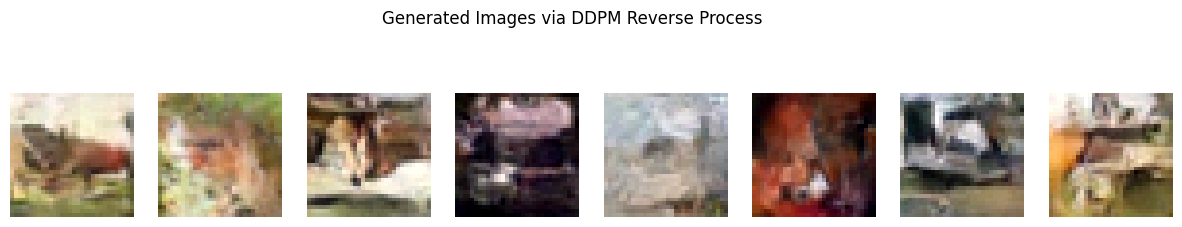

In [32]:
import torch
import torch.nn.functional as F # Import F for pad if DDPMScheduler is redefined
import matplotlib.pyplot as plt

# Redefine DDPMScheduler to ensure the 'step' method is included
# This is a workaround as the DDPMScheduler in hqgB-eQYv6TK did not contain the 'step' method
class DDPMScheduler:
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device="cpu"):
        self.num_timesteps = num_timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        # Include alphas_cumprod_prev needed for the step method
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

    def add_noise(self, clean_images, noise, timesteps):
        sqrt_alpha_cumprod = torch.sqrt(self.alphas_cumprod[timesteps]).view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod = torch.sqrt(1.0 - self.alphas_cumprod[timesteps]).view(-1, 1, 1, 1)
        return sqrt_alpha_cumprod * clean_images + sqrt_one_minus_alpha_cumprod * noise

    def step(self, predicted_noise, timestep, current_image):
        t = timestep
        alpha_t = self.alphas[t]
        alpha_cumprod_t = self.alphas_cumprod[t]
        beta_t = self.betas[t]

        coef1 = 1.0 / torch.sqrt(alpha_t)
        coef2 = (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_cumprod_t)
        pred_prev_image = coef1 * (current_image - coef2 * predicted_noise)

        if t > 0:
            variance = torch.sqrt(beta_t)
            noise = torch.randn_like(current_image).to(self.device)
            pred_prev_image = pred_prev_image + variance * noise

        return pred_prev_image

# 1. Setup Device and Load the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the exact same U-Net and Scheduler
# SharedUNet is assumed to be correctly defined in a previous cell and in scope
model = SharedUNet().to(device)
scheduler = DDPMScheduler(device=device)

# Load your trained weights
model.load_state_dict(torch.load("ddpm_unet_cifar10.pth", map_location=device))
model.eval() # Set model to evaluation mode

print("Model loaded successfully. Starting reverse diffusion...")

# 2. The Reverse Sampling Loop
@torch.no_grad() # Disable gradient calculation for faster inference
def generate_samples(model, scheduler, num_samples=4):
    # Start with pure random Gaussian noise
    current_images = torch.randn(num_samples, 3, 32, 32).to(device)

    # Loop backwards from T-1 down to 0
    for t in reversed(range(scheduler.num_timesteps)):
        # Create a tensor of the current timestep
        timesteps = torch.full((num_samples,), t, device=device, dtype=torch.long)

        # Predict the noise using your trained U-Net
        predicted_noise = model(current_images, timesteps)

        # Step backwards to remove a fraction of the noise
        current_images = scheduler.step(predicted_noise, t, current_images)

        # Optional: Print progress every 100 steps so you know it hasn't frozen
        if t % 100 == 0:
            print(f"Sampling step {t}/{scheduler.num_timesteps}...")

    # Scale pixel values from [-1, 1] back to [0, 1] for matplotlib
    final_images = (current_images.clamp(-1, 1) + 1) / 2.0
    return final_images.cpu()

# 3. Generate and Visualize
generated_images = generate_samples(model, scheduler, num_samples=8)

# Plotting the results
fig, axes = plt.subplots(1, 8, figsize=(15, 3))
for i in range(8):
    # PyTorch is (C, H, W), Matplotlib expects (H, W, C)
    img = generated_images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis("off")

plt.suptitle("Generated Images via DDPM Reverse Process")
plt.show()

In [33]:
import torch

class DDIMScheduler:
    def __init__(self, num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02, device="cpu"):
        self.num_train_timesteps = num_train_timesteps
        self.device = device

        # 1. Same base noise schedule as DDPM
        self.betas = torch.linspace(beta_start, beta_end, num_train_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

        # Will be populated when we choose how many steps to skip
        self.timesteps = None

    def set_timesteps(self, num_inference_steps=50):
        """Calculates the specific timesteps to visit during the skipped reverse process."""
        step_ratio = self.num_train_timesteps // num_inference_steps
        # Create a sequence of timesteps to evaluate (e.g., 999, 979, 959... down to 0)
        timesteps = (torch.arange(0, num_inference_steps) * step_ratio).round().long()
        self.timesteps = timesteps.flip(0).to(self.device)

    def step(self, predicted_noise, timestep, prev_timestep, current_image):
        """
        The DDIM deterministic reverse step.
        """
        # Fetch cumulative alphas
        alpha_cumprod_t = self.alphas_cumprod[timestep]

        # If prev_timestep is less than 0, alpha_cumprod_t_prev is 1.0 (pure clean image)
        alpha_cumprod_t_prev = self.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else torch.tensor(1.0, device=self.device)

        # 1. Predict the original clean image (x_0)
        pred_original_sample = (current_image - torch.sqrt(1 - alpha_cumprod_t) * predicted_noise) / torch.sqrt(alpha_cumprod_t)

        # 2. Calculate the direction pointing back to x_t
        dir_xt = torch.sqrt(1 - alpha_cumprod_t_prev) * predicted_noise

        # 3. Compute the previous image x_{t-1}
        pred_prev_image = torch.sqrt(alpha_cumprod_t_prev) * pred_original_sample + dir_xt

        return pred_prev_image

Model loaded. Starting DDIM fast inference with 50 steps...
Generation completed in 0.26 seconds!


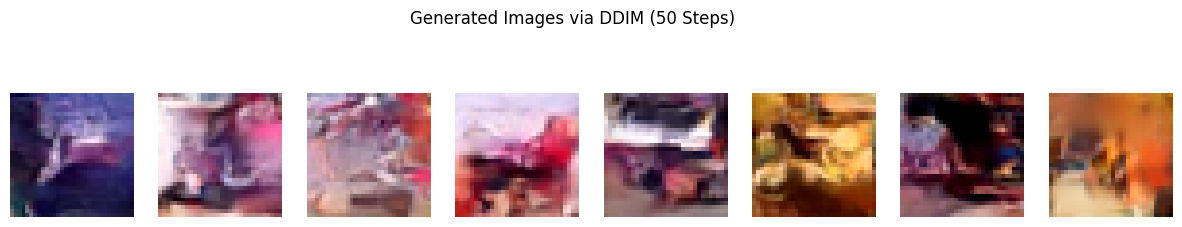

In [34]:
import matplotlib.pyplot as plt
import time

# 1. Setup Device and load your ALREADY TRAINED U-Net
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SharedUNet().to(device)

# Load the weights generated from the DDPM training phase
model.load_state_dict(torch.load("ddpm_unet_cifar10.pth", map_location=device))
model.eval()

# 2. Initialize the DDIM Scheduler for 50 inference steps
ddim_scheduler = DDIMScheduler(device=device)
num_inference_steps = 50
ddim_scheduler.set_timesteps(num_inference_steps)

print(f"Model loaded. Starting DDIM fast inference with {num_inference_steps} steps...")

# 3. The Accelerated Reverse Sampling Loop
@torch.no_grad()
def generate_ddim_samples(model, scheduler, num_samples=8):
    # Start with pure noise
    current_images = torch.randn(num_samples, 3, 32, 32).to(device)

    start_time = time.time()

    # Loop over the custom shortened sequence of timesteps
    for i, t in enumerate(scheduler.timesteps):
        # The current timestep
        timestep_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)

        # Calculate what the previous timestep should be in our skipped sequence
        prev_t = scheduler.timesteps[i + 1] if i < len(scheduler.timesteps) - 1 else -1

        # Predict the noise
        predicted_noise = model(current_images, timestep_tensor)

        # Take a DDIM step
        current_images = scheduler.step(predicted_noise, t, prev_t, current_images)

    generation_time = time.time() - start_time
    print(f"Generation completed in {generation_time:.2f} seconds!")

    # Scale back to [0, 1] for viewing
    final_images = (current_images.clamp(-1, 1) + 1) / 2.0
    return final_images.cpu()

# 4. Generate and Visualize
ddim_generated_images = generate_ddim_samples(model, ddim_scheduler)

fig, axes = plt.subplots(1, 8, figsize=(15, 3))
for i in range(8):
    img = ddim_generated_images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis("off")

plt.suptitle(f"Generated Images via DDIM (50 Steps)")
plt.show()

In [35]:
import torch
import math

class ImprovedDDPMScheduler:
    def __init__(self, num_timesteps=1000, offset=0.008, max_beta=0.999, device="cpu"):
        self.num_timesteps = num_timesteps
        self.device = device

        # 1. Direct calculation of Alpha Cumprod using the Cosine Formula
        timesteps = torch.linspace(0, num_timesteps, num_timesteps + 1, device=device)
        alphas_cumprod_func = torch.cos(((timesteps / num_timesteps) + offset) / (1 + offset) * (math.pi / 2)) ** 2
        self.alphas_cumprod = alphas_cumprod_func / alphas_cumprod_func[0]

        # 2. Derive Betas from the Alpha Cumprod
        betas = []
        for i in range(num_timesteps):
            t_prev = self.alphas_cumprod[i]
            t_curr = self.alphas_cumprod[i + 1]

            # FIX 1: Added 1e-8 to prevent division by zero if t_prev gets too small
            beta_t = 1.0 - (t_curr / (t_prev + 1e-8))
            betas.append(torch.clamp(beta_t, max=max_beta))

        self.betas = torch.stack(betas).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = self.alphas_cumprod[1:]

    def add_noise(self, clean_images, noise, timesteps):
        sqrt_alpha_cumprod = torch.sqrt(self.alphas_cumprod[timesteps]).view(-1, 1, 1, 1)

        # FIX 1: Added 1e-8 inside the square root for numerical stability
        sqrt_one_minus_alpha_cumprod = torch.sqrt(1.0 - self.alphas_cumprod[timesteps] + 1e-8).view(-1, 1, 1, 1)

        return sqrt_alpha_cumprod * clean_images + sqrt_one_minus_alpha_cumprod * noise

    def step(self, predicted_noise, timestep, current_image):
        t = timestep
        alpha_t = self.alphas[t]
        alpha_cumprod_t = self.alphas_cumprod[t]
        beta_t = self.betas[t]

        # FIX 1: Added 1e-8 to denominators to prevent infinite values
        coef1 = 1.0 / torch.sqrt(alpha_t + 1e-8)
        coef2 = (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_cumprod_t + 1e-8)

        pred_prev_image = coef1 * (current_image - coef2 * predicted_noise)

        # FIX 2: Clamp the image safely to pixel bounds to prevent the black square collapse
        pred_prev_image = torch.clamp(pred_prev_image, -1.0, 1.0)

        if t > 0:
            variance = torch.sqrt(beta_t)
            noise = torch.randn_like(current_image).to(self.device)
            pred_prev_image = pred_prev_image + variance * noise

        return pred_prev_image

In [36]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.transforms import GaussianBlur

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training Improved DDPM on: {device}")

# --- Re-define DeblurDataset and train_loader for this cell's context ---
# (Copied from hqgB-eQYv6TK to ensure availability)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

blur_transform = GaussianBlur(kernel_size=5, sigma=(2.0, 2.0))

class DeblurDataset(torch.utils.data.Dataset):
    def __init__(self, root='./data', train=True):
        self.base_dataset = torchvision.datasets.CIFAR10(
            root=root, train=train, download=True, transform=base_transform
        )

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        clean_img, _ = self.base_dataset[idx]
        blurry_img = blur_transform(clean_img)
        return clean_img, blurry_img

train_dataset = DeblurDataset(train=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
# ----------------------------------------------------------------------

# 2. Instantiate Model and the Stable Cosine Scheduler
model_improved = SharedUNet().to(device)
improved_scheduler = ImprovedDDPMScheduler(device=device)

# We use the same learning rate for a fair comparison
optimizer = torch.optim.AdamW(model_improved.parameters(), lr=2e-4)

# Bumping up to 20 epochs to give the model time to form better shapes
epochs = 20

print("Starting Improved DDPM (Cosine Schedule) training loop...")
for epoch in range(epochs):
    model_improved.train()
    epoch_loss = 0.0

    for step, (clean_images, blurry_images) in enumerate(train_loader):
        clean_images = clean_images.to(device)
        batch_size = clean_images.shape[0]

        # Sample noise and random timesteps
        noise = torch.randn_like(clean_images).to(device)
        timesteps = torch.randint(0, improved_scheduler.num_timesteps, (batch_size,), device=device).long()

        # Generate target noisy images using the Cosine Schedule
        noisy_images = improved_scheduler.add_noise(clean_images, noise, timesteps)

        # Optimize
        optimizer.zero_grad()
        predicted_noise = model_improved(noisy_images, timesteps)
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward()

        # FIX 3: Gradient Clipping. This physically stops the weights from exploding
        torch.nn.utils.clip_grad_norm_(model_improved.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Average Loss: {epoch_loss / len(train_loader):.6f}")

# Save the newly trained stable weights
torch.save(model_improved.state_dict(), "improved_ddpm_unet_cifar10.pth")
print("Training complete! Model saved as improved_ddpm_unet_cifar10.pth")

Training Improved DDPM on: cuda
Starting Improved DDPM (Cosine Schedule) training loop...
Epoch 01/20 | Average Loss: 0.124844
Epoch 02/20 | Average Loss: 0.076849
Epoch 03/20 | Average Loss: 0.072248
Epoch 04/20 | Average Loss: 0.070510
Epoch 05/20 | Average Loss: 0.068171
Epoch 06/20 | Average Loss: 0.067682
Epoch 07/20 | Average Loss: 0.066120
Epoch 08/20 | Average Loss: 0.065649
Epoch 09/20 | Average Loss: 0.065041
Epoch 10/20 | Average Loss: 0.065501
Epoch 11/20 | Average Loss: 0.064155
Epoch 12/20 | Average Loss: 0.064330
Epoch 13/20 | Average Loss: 0.063327
Epoch 14/20 | Average Loss: 0.062787
Epoch 15/20 | Average Loss: 0.063649
Epoch 16/20 | Average Loss: 0.062256
Epoch 17/20 | Average Loss: 0.062744
Epoch 18/20 | Average Loss: 0.063304
Epoch 19/20 | Average Loss: 0.063277
Epoch 20/20 | Average Loss: 0.062538
Training complete! Model saved as improved_ddpm_unet_cifar10.pth


Model loaded. Starting reverse diffusion with Cosine Schedule...
Sampling step 900/1000...
Sampling step 800/1000...
Sampling step 700/1000...
Sampling step 600/1000...
Sampling step 500/1000...
Sampling step 400/1000...
Sampling step 300/1000...
Sampling step 200/1000...
Sampling step 100/1000...
Sampling step 0/1000...


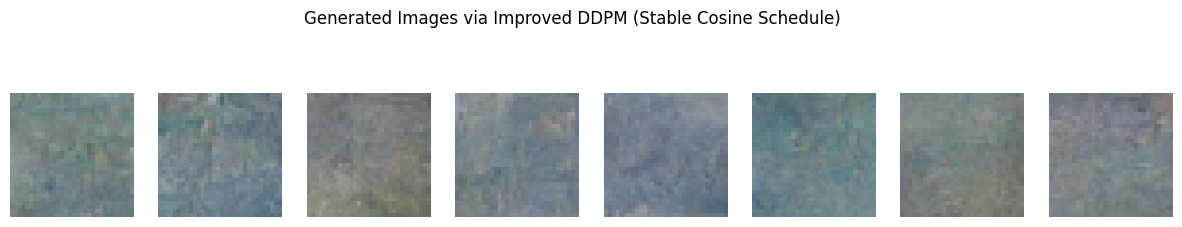

In [37]:
import matplotlib.pyplot as plt

# 1. Load the Model and Weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_improved = SharedUNet().to(device)
model_improved.load_state_dict(torch.load("improved_ddpm_unet_cifar10.pth", map_location=device))
model_improved.eval()

# 2. Initialize the Cosine Scheduler
improved_scheduler = ImprovedDDPMScheduler(device=device)

print("Model loaded. Starting reverse diffusion with Cosine Schedule...")

# 3. The Reverse Sampling Loop
@torch.no_grad()
def generate_improved_samples(model, scheduler, num_samples=8):
    # Start with pure random Gaussian noise
    current_images = torch.randn(num_samples, 3, 32, 32).to(device)

    # Loop backwards from T-1 down to 0
    for t in reversed(range(scheduler.num_timesteps)):
        timesteps = torch.full((num_samples,), t, device=device, dtype=torch.long)

        # Predict the noise
        predicted_noise = model(current_images, timesteps)

        # Step backwards using the cosine-derived variance and alphas
        current_images = scheduler.step(predicted_noise, t, current_images)

        if t % 100 == 0:
            print(f"Sampling step {t}/{scheduler.num_timesteps}...")

    # Scale pixel values from [-1, 1] back to [0, 1] for matplotlib
    final_images = (current_images.clamp(-1, 1) + 1) / 2.0
    return final_images.cpu()

# 4. Generate and Visualize
improved_generated_images = generate_improved_samples(model_improved, improved_scheduler, num_samples=8)

# Plotting the results
fig, axes = plt.subplots(1, 8, figsize=(15, 3))
for i in range(8):
    img = improved_generated_images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis("off")

plt.suptitle("Generated Images via Improved DDPM (Stable Cosine Schedule)")
plt.show()

In [38]:
import torch

class ScoreSDEScheduler:
    def __init__(self, beta_min=0.1, beta_max=20.0, device="cpu"):
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.device = device

    def marginal_prob(self, x, t):
        """Calculates the mean and standard deviation at any continuous time t in (0, 1]."""
        # The integral of beta(t) for VP-SDE
        log_mean_coeff = -0.25 * t ** 2 * (self.beta_max - self.beta_min) - 0.5 * t * self.beta_min

        mean = torch.exp(log_mean_coeff).view(-1, 1, 1, 1) * x
        std = torch.sqrt(1.0 - torch.exp(2.0 * log_mean_coeff) + 1e-8).view(-1, 1, 1, 1)
        return mean, std

    def add_noise(self, clean_images, noise, t):
        """FORWARD SDE: Injects noise based on the continuous time marginals."""
        mean, std = self.marginal_prob(clean_images, t)
        return mean + std * noise

    def step(self, predicted_noise, current_image, t, dt):
        """REVERSE SDE: Euler-Maruyama numerical step to solve the differential equation."""
        # 1. Convert the U-Net's noise prediction into the continuous "Score"
        _, std = self.marginal_prob(current_image, t)
        score = -predicted_noise / std

        # 2. Calculate continuous beta at time t
        beta_t = self.beta_min + t * (self.beta_max - self.beta_min)
        beta_t = beta_t.view(-1, 1, 1, 1)

        # 3. Calculate the Drift and Diffusion terms of the Reverse SDE
        drift = -0.5 * beta_t * current_image - 0.5 * beta_t * score
        diffusion = torch.sqrt(beta_t)

        # 4. Inject structural noise (z) for the probabilistic step backwards
        z = torch.randn_like(current_image) if t.max() > dt.max() else torch.zeros_like(current_image)

        # 5. The Euler-Maruyama Update (Subtract drift, add diffusion)
        pred_prev_image = current_image - drift * dt + diffusion * torch.sqrt(dt) * z

        # Clamp to prevent numerical instability
        return torch.clamp(pred_prev_image, -1.0, 1.0)

In [39]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training Score SDE on: {device}")

model_sde = SharedUNet().to(device)
sde_scheduler = ScoreSDEScheduler(device=device)
optimizer = torch.optim.AdamW(model_sde.parameters(), lr=2e-4)
epochs = 20

print("Starting Score SDE (Continuous-Time) training loop...")
for epoch in range(epochs):
    model_sde.train()
    epoch_loss = 0.0

    for step, (clean_images, blurry_images) in enumerate(train_loader):
        clean_images = clean_images.to(device)
        batch_size = clean_images.shape[0]

        # Sample continuous time uniformly between a small epsilon (1e-5) and 1.0
        # Epsilon prevents division by zero at t=0
        t_continuous = torch.rand((batch_size,), device=device) * (1.0 - 1e-5) + 1e-5

        # Map continuous t to discrete 0-999 for the U-Net's Positional Embedding layer
        t_embedded = (t_continuous * 999).long()

        noise = torch.randn_like(clean_images).to(device)
        noisy_images = sde_scheduler.add_noise(clean_images, noise, t_continuous)

        optimizer.zero_grad()
        predicted_noise = model_sde(noisy_images, t_embedded)
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward()

        # Gradient clipping for stable training
        torch.nn.utils.clip_grad_norm_(model_sde.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Average Loss: {epoch_loss / len(train_loader):.6f}")

torch.save(model_sde.state_dict(), "score_sde_unet_cifar10.pth")
print("Training complete! Model saved as score_sde_unet_cifar10.pth")

Training Score SDE on: cuda
Starting Score SDE (Continuous-Time) training loop...
Epoch 01/20 | Average Loss: 0.084084
Epoch 02/20 | Average Loss: 0.043723
Epoch 03/20 | Average Loss: 0.040359
Epoch 04/20 | Average Loss: 0.039601
Epoch 05/20 | Average Loss: 0.037697
Epoch 06/20 | Average Loss: 0.037045
Epoch 07/20 | Average Loss: 0.036463
Epoch 08/20 | Average Loss: 0.035682
Epoch 09/20 | Average Loss: 0.035685
Epoch 10/20 | Average Loss: 0.035883
Epoch 11/20 | Average Loss: 0.035272
Epoch 12/20 | Average Loss: 0.035123
Epoch 13/20 | Average Loss: 0.034964
Epoch 14/20 | Average Loss: 0.034490
Epoch 15/20 | Average Loss: 0.034480
Epoch 16/20 | Average Loss: 0.034765
Epoch 17/20 | Average Loss: 0.034447
Epoch 18/20 | Average Loss: 0.034338
Epoch 19/20 | Average Loss: 0.034456
Epoch 20/20 | Average Loss: 0.034096
Training complete! Model saved as score_sde_unet_cifar10.pth


Model loaded. Starting Reverse SDE generation...
Solving SDE step 0/1000 (t=1.000)...
Solving SDE step 200/1000 (t=0.800)...
Solving SDE step 400/1000 (t=0.600)...
Solving SDE step 600/1000 (t=0.400)...
Solving SDE step 800/1000 (t=0.200)...


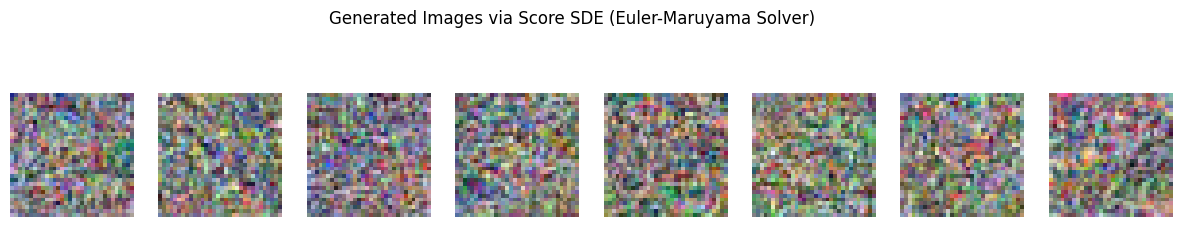

In [40]:
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_sde = SharedUNet().to(device)
model_sde.load_state_dict(torch.load("score_sde_unet_cifar10.pth", map_location=device))
model_sde.eval()

sde_scheduler = ScoreSDEScheduler(device=device)
print("Model loaded. Starting Reverse SDE generation...")

@torch.no_grad()
def generate_sde_samples(model, scheduler, num_samples=8, num_steps=1000):
    # Start with pure random Gaussian noise at t = 1.0
    current_images = torch.randn(num_samples, 3, 32, 32).to(device)

    # Define continuous time steps from 1.0 down to a small epsilon (1e-3)
    time_steps = torch.linspace(1.0, 1e-3, num_steps, device=device)
    dt = torch.tensor([1.0 / num_steps], device=device)

    for i in range(num_steps):
        t = time_steps[i]
        t_tensor = torch.full((num_samples,), t, device=device)

        # Map continuous t to the U-Net's discrete embedding space
        t_embedded = (t_tensor * 999).long()

        # Predict noise
        predicted_noise = model(current_images, t_embedded)

        # Solve the SDE backward by one step (dt)
        current_images = scheduler.step(predicted_noise, current_images, t_tensor, dt)

        if i % 200 == 0:
            print(f"Solving SDE step {i}/{num_steps} (t={t.item():.3f})...")

    final_images = (current_images.clamp(-1, 1) + 1) / 2.0
    return final_images.cpu()

sde_generated_images = generate_sde_samples(model_sde, sde_scheduler, num_samples=8)

fig, axes = plt.subplots(1, 8, figsize=(15, 3))
for i in range(8):
    img = sde_generated_images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis("off")

plt.suptitle("Generated Images via Score SDE (Euler-Maruyama Solver)")
plt.show()